In [1]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 21.0 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.8/16.8 MB 86.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 76.7 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 39.0 MB/s eta 0:00:0000:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 35.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 7.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 3.0 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
!pip uninstall -y numpy opencv-python opencv-python-headless albumentations

!pip install "numpy<2" opencv-python-headless albumentations

Found existing installation: numpy 2.2.6
Uninstalling numpy-2.2.6:
  Successfully uninstalled numpy-2.2.6
Found existing installation: opencv-python 4.12.0.88
Uninstalling opencv-python-4.12.0.88:
  Successfully uninstalled opencv-python-4.12.0.88
Found existing installation: opencv-python-headless 4.12.0.88
Uninstalling opencv-python-headless-4.12.0.88:
  Successfully uninstalled opencv-python-headless-4.12.0.88
Found existing installation: albumentations 2.0.8
Uninstalling albumentations-2.0.8:
  Successfully uninstalled albumentations-2.0.8
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 kB 3.7 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of opencv-python-headless to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 95.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [3]:
from ultralytics import YOLO
import os
import glob

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [4]:
data_root = "/kaggle/input/trash-icra19"

yolo_data_yaml = f"""
path: {data_root}

train: train/images
val: val/images
test: test/images

names:
  0: plastic
  1: biological
  2: ROV
"""

yaml_path = "/kaggle/working/trash_icra19.yaml"
with open(yaml_path, "w") as f:
    f.write(yolo_data_yaml)

print("yaml path", yaml_path)

yaml path /kaggle/working/trash_icra19.yaml


In [ ]:
for split in ["train", "val", "test"]:
    img_dir = os.path.join(data_root, split, "images")
    lbl_dir = os.path.join(data_root, split, "labels")
    print(f"{split} images:", len(glob.glob(os.path.join(img_dir, "*.jpg"))))
    print(f"{split} labels:", len(glob.glob(os.path.join(lbl_dir, "*.txt"))))

In [ ]:
model = YOLO("yolov8m.pt")

results = model.train(
    data=yaml_path,     
    imgsz=1024,         
    epochs=50,          
    batch=8,         
    project="Underwater_object_detection",
    name="yolov8m_trash_icra19",
    exist_ok=True,
)

In [5]:
from ultralytics import YOLO

best_model_path = "/kaggle/input/underwater-objectdetection-yolov8/pytorch/default/1/Underwater_object_detection/yolov8m_trash_icra19/weights/best.pt"
yolo_model = YOLO(best_model_path)
print("Loaded YOLO best model!")

Loaded YOLO best model!


In [6]:
yolo_test_results = yolo_model.val(data=yaml_path, split='test', imgsz=1024)

Ultralytics 8.3.233 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 92 layers, 25,841,497 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 12.0±6.2 MB/s, size: 25.3 KB)
val: Scanning /kaggle/input/trash-icra19/test/labels... 1144 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1144/1144 477.8it/s 2.4s0.0s
WARNING ⚠️ val: Cache directory /kaggle/input/trash-icra19/test is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 72/72 1.5it/s 49.5s0.8ss


/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all       1144       1668      0.961      0.964      0.984      0.813
               plastic        858        937      0.988      0.982      0.993      0.775
            biological        322        396      0.953      0.967      0.986      0.828
                   ROV        258        335      0.943      0.943      0.974      0.835
Speed: 1.5ms preprocess, 38.1ms inference, 0.0ms loss, 0.6ms postprocess per image
Results saved to /kaggle/working/runs/detect/val


In [15]:
metrics = yolo_test_results
cm = metrics.confusion_matrix
curves = metrics.curves_results
names = metrics.names

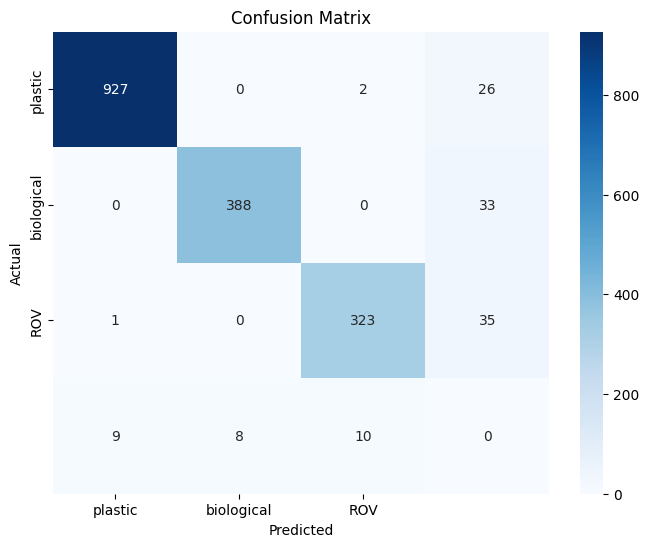

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_confusion_matrix(cm, class_names):
    matrix = cm.matrix  # raw matrix
    plt.figure(figsize=(8,6))
    sns.heatmap(matrix, annot=True, fmt=".0f", cmap="Blues",
                xticklabels=class_names,
                yticklabels=class_names)
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

plot_confusion_matrix(cm, list(names.values()))

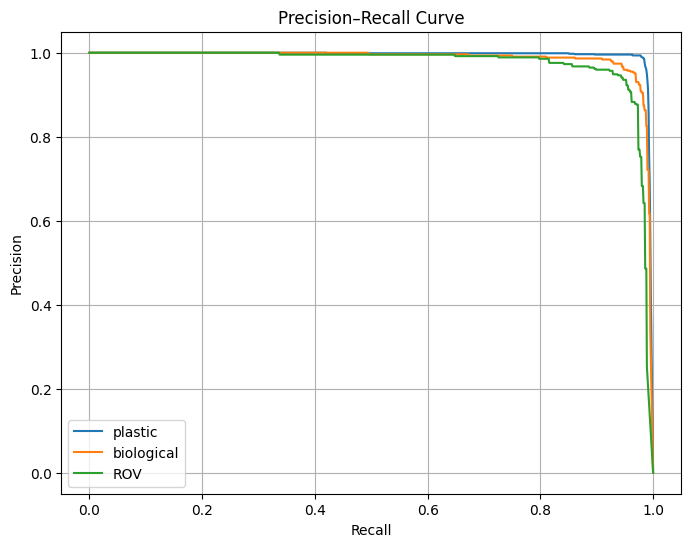

In [17]:
def plot_pr_curve(metrics, names):
    x, y, xlabel, ylabel = metrics.curves_results[0]

    plt.figure(figsize=(8,6))
    for cls_idx in range(len(names)):
        plt.plot(x, y[cls_idx], label=names[cls_idx])

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title("Precision–Recall Curve")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_pr_curve(metrics, names)

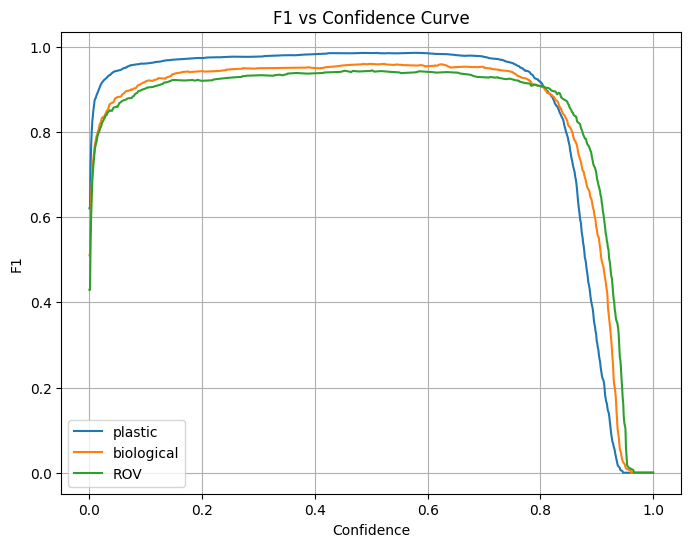

In [18]:
def plot_f1_conf_curve(metrics, names):
    x, y, xlabel, ylabel = metrics.curves_results[1]

    plt.figure(figsize=(8,6))
    for cls_idx in range(len(names)):
        plt.plot(x, y[cls_idx], label=names[cls_idx])

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title("F1 vs Confidence Curve")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_f1_conf_curve(metrics, names)

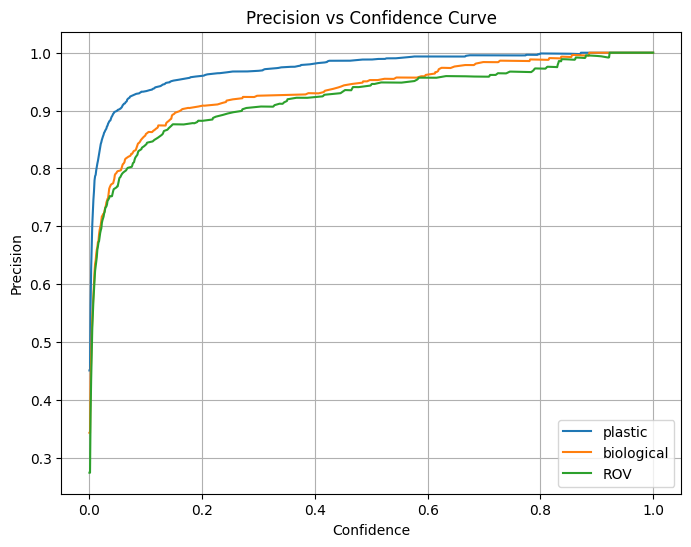

In [19]:
def plot_precision_conf_curve(metrics, names):
    x, y, xlabel, ylabel = metrics.curves_results[2]

    plt.figure(figsize=(8,6))
    for cls_idx in range(len(names)):
        plt.plot(x, y[cls_idx], label=names[cls_idx])

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title("Precision vs Confidence Curve")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_precision_conf_curve(metrics, names)

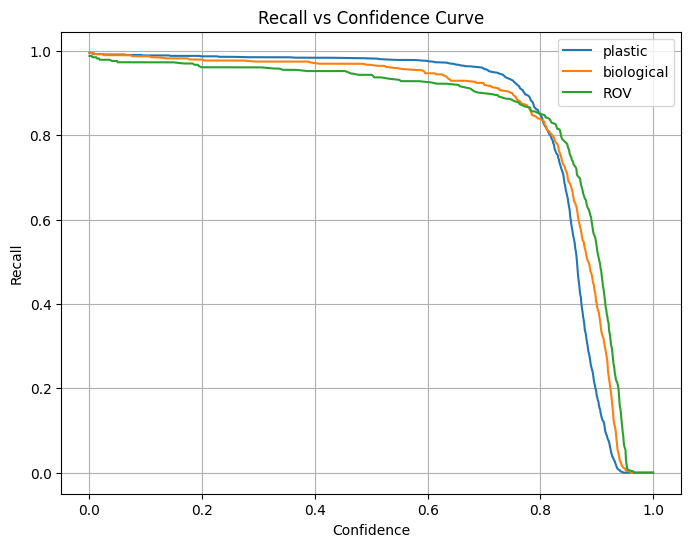

In [20]:
def plot_recall_conf_curve(metrics, names):
    x, y, xlabel, ylabel = metrics.curves_results[3]

    plt.figure(figsize=(8,6))
    for cls_idx in range(len(names)):
        plt.plot(x, y[cls_idx], label=names[cls_idx])

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title("Recall vs Confidence Curve")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_recall_conf_curve(metrics, names)

In [22]:
import pandas as pd

df_results = pd.DataFrame({
    "Class": list(names.values()),
    "Support": metrics.nt_per_class,
    "AP@50-95": metrics.maps
})

df_results

,Class,Support,AP@50-95
0,plastic,937,0.775088
1,biological,396,0.827895
2,ROV,335,0.835168


In [23]:
summary = metrics.results_dict
for k, v in summary.items():
    print(f"{k}: {v:.4f}")

metrics/precision(B): 0.9614
metrics/recall(B): 0.9641
metrics/mAP50(B): 0.9842
metrics/mAP50-95(B): 0.8127
fitness: 0.8127


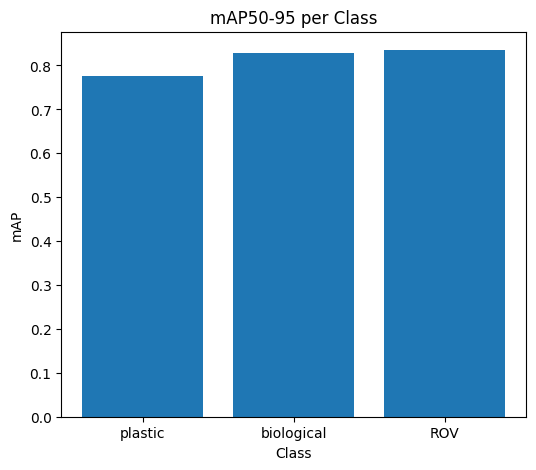

In [24]:
plt.figure(figsize=(6,5))
plt.bar(names.values(), metrics.maps)
plt.title("mAP50-95 per Class")
plt.ylabel("mAP")
plt.xlabel("Class")
plt.show()

In [25]:
from ultralytics import YOLO

model_path = "/kaggle/input/underwater-objectdetection-yolov8/pytorch/default/1/Underwater_object_detection/yolov8m_trash_icra19/weights/best.pt"
model = YOLO(model_path)

print("Model loaded!")


Model loaded!


In [26]:
import os

test_images_dir = "/kaggle/input/trash-icra19/test/images"

results = model.predict(
    source=test_images_dir,  
    imgsz=1024,
    save=True,            
    save_txt=True,         
    conf=0.25,            
    iou=0.5,              
    project="/kaggle/working/runs/detect",
    name="test_inference",
    exist_ok=True
)

print("Inference completed!")


WARNING ⚠️ 
inference results will accumulate in RAM unless `stream=True` is passed, causing potential out-of-memory
errors for large sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

image 1/1144 /kaggle/input/trash-icra19/test/images/bio0000_frame0000016.jpg: 768x1024 2 biologicals, 63.0ms
image 2/1144 /kaggle/input/trash-icra19/test/images/bio0000_frame0000041.jpg: 768x1024 2 biologicals, 39.8ms
image 3/1144 /kaggle/input/trash-icra19/test/images/bio0000_frame0000043.jpg: 768x1024 2 biologicals, 40.2ms
image 4/1144 /kaggle/input/trash-icra19/test/images/bio0000_frame0000073.jpg: 768x1024 2 biologicals, 40.9ms
image 5/1144 /kaggle

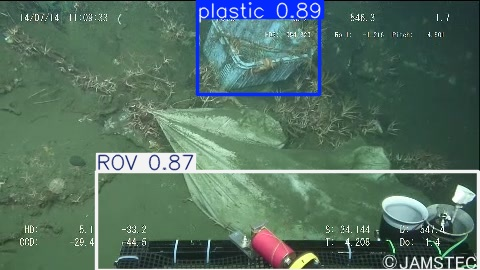

In [29]:
import random
from IPython.display import Image, display

output_dir = "/kaggle/working/runs/detect/test_inference"
sample_img = random.choice([f for f in os.listdir(output_dir) if f.endswith(".jpg")])

display(Image(filename=os.path.join(output_dir, sample_img)))